In [2]:
import numpy as np
import pandas as pd

# Классификация

In [3]:
df = pd.read_csv("Data/WineQT.csv")

## Датасет WineQuality

In [4]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595


In [5]:
df["quality"].unique()

array([5, 6, 7, 4, 8, 3])

In [6]:
df["quality"].value_counts()

quality
5    483
6    462
7    143
4     33
8     16
3      6
Name: count, dtype: int64

In [7]:
df = df.drop(["Id"], axis=1)
df["quality"] -= 3

## Обучения ансамбля

In [8]:
from ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

In [9]:
X = df.drop(["quality"], axis=1)
y = df["quality"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [10]:
model = RandomForestClassifier(max_depth=40)

In [11]:
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=40)

## Проверка модели и сравнение с sklearn

In [12]:
from sklearn.ensemble import RandomForestClassifier as RFC

In [13]:
model_rfc = RFC(max_depth=40)
model_rfc.fit(X_train, y_train)

RandomForestClassifier(max_depth=40)

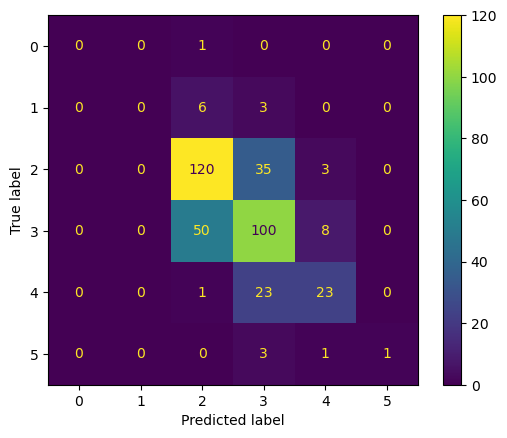

In [14]:
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

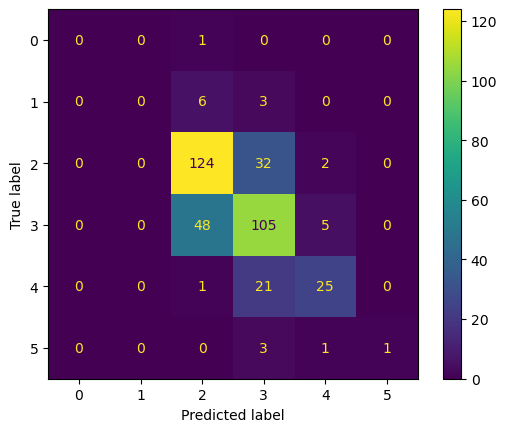

In [15]:
ConfusionMatrixDisplay.from_estimator(model_rfc, X_test, y_test)

In [16]:
y_pred = model.predict(X_test)
y_pred_r = model_rfc.predict(X_test)

print(classification_report(y_test, y_pred))
print(classification_report(y_test, y_pred_r))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         9
           2       0.67      0.76      0.71       158
           3       0.61      0.63      0.62       158
           4       0.66      0.49      0.56        47
           5       1.00      0.20      0.33         5

    accuracy                           0.65       378
   macro avg       0.49      0.35      0.37       378
weighted avg       0.63      0.65      0.63       378

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         9
           2       0.69      0.78      0.73       158
           3       0.64      0.66      0.65       158
           4       0.76      0.53      0.62        47
           5       1.00      0.20      0.33         5

    accuracy                           0.67       378
   macro avg       0.51

c:\Users\danil\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\danil\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\danil\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\danil\anaconda3\Lib\site-packag